In [ ]:
!pip install opencv-python

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
import cv2
import random
import matplotlib.pyplot as plt

**CIFAR-10 (For Parts 1 – 3)**

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

100%|██████████| 170M/170M [00:05<00:00, 29.0MB/s]


**Part 1: The Dimensionality Crisis (FFN)**

In [ ]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072,512), nn.ReLU(),
            nn.Linear(512,512), nn.ReLU(),
            nn.Linear(512,512), nn.ReLU(),
            nn.Linear(512,10)
        )

    def forward(self,x):
        return self.net(x.view(x.size(0),-1))

In [ ]:
ffn = FFN()
opt = optim.Adam(ffn.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for e in range(5):
    for x,y in train_loader:
        opt.zero_grad()
        loss = loss_fn(ffn(x), y)
        loss.backward()
        opt.step()
    print("FFN Epoch:", e+1)

FFN Epoch: 1
FFN Epoch: 2
FFN Epoch: 3
FFN Epoch: 4
FFN Epoch: 5


In [ ]:
def shift(img):
    return torch.roll(img, shifts=4, dims=2)

img,_ = test_dataset[0]

orig = ffn(img.unsqueeze(0))
shifted = ffn(shift(img).unsqueeze(0))

print("Original:", torch.softmax(orig,1).max())
print("Shifted:", torch.softmax(shifted,1).max())

Original: tensor(0.7226, grad_fn=<MaxBackward1>)
Shifted: tensor(0.4542, grad_fn=<MaxBackward1>)


**Part 2: The CNN Baseline**

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU()
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128,10)

    def forward(self,x):
        x = self.conv(x)
        x = self.gap(x)
        return self.fc(x.view(x.size(0),-1))

In [ ]:
cnn = CNN()
opt = optim.Adam(cnn.parameters(), lr=0.001)

for e in range(15):
    for x,y in train_loader:
        opt.zero_grad()
        loss = loss_fn(cnn(x), y)
        loss.backward()
        opt.step()

In [ ]:
correct=0; total=0

cnn.eval()
with torch.no_grad():
    for x,y in test_loader:
        _,p = torch.max(cnn(x),1)
        total+=y.size(0)
        correct+=(p==y).sum().item()

print("CNN Accuracy:",100*correct/total)

CNN Accuracy: 63.29


In [ ]:
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(512,10)

opt = optim.Adam(resnet.parameters(), lr=0.0001)

for e in range(5):
    for x,y in train_loader:
        opt.zero_grad()
        loss = loss_fn(resnet(x), y)
        loss.backward()
        opt.step()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


In [ ]:
correct=0; total=0

resnet.eval()
with torch.no_grad():
    for x,y in test_loader:
        _,p = torch.max(resnet(x),1)
        total+=y.size(0)
        correct+=(p==y).sum().item()

print("ResNet Accuracy:",100*correct/total)

ResNet Accuracy: 81.73


**Part 3: MobileNet & Efficiency**

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.depthwise = nn.Conv2d(in_c, in_c, 3, padding=1, groups=in_c)
        self.pointwise = nn.Conv2d(in_c, out_c, 1)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))

In [ ]:
class MobileCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            DepthwiseSeparableConv(3, 32), nn.ReLU(),
            DepthwiseSeparableConv(32, 64), nn.ReLU(),
            DepthwiseSeparableConv(64, 128), nn.ReLU()
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

**BCCD Dataset**

In [ ]:
!git clone https://github.com/Shenggan/BCCD_Dataset.git

Cloning into 'BCCD_Dataset'...
remote: Enumerating objects: 800, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 800 (delta 8), reused 6 (delta 6), pack-reused 789 (from 1)
Receiving objects: 100% (800/800), 7.39 MiB | 28.98 MiB/s, done.
Resolving deltas: 100% (379/379), done.


In [ ]:
img_dir="BCCD_Dataset/BCCD/JPEGImages"
ann_dir="BCCD_Dataset/BCCD/Annotations"

imgs=os.listdir(img_dir)
random.shuffle(imgs)

split=int(0.8*len(imgs))
train_imgs=imgs[:split]
test_imgs=imgs[split:]

In [ ]:
class BCCD(Dataset):
    def __init__(self,imgs):
        self.imgs=imgs

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self,i):
        name=self.imgs[i]
        img=cv2.imread(os.path.join(img_dir,name))
        h,w,_=img.shape

        root=ET.parse(os.path.join(ann_dir,name.split('.')[0]+'.xml')).getroot()

        objects=root.findall('object')

        max_area=0
        for obj in objects:
            b=obj.find('bndbox')
            xmin=int(b.find('xmin').text)
            ymin=int(b.find('ymin').text)
            xmax=int(b.find('xmax').text)
            ymax=int(b.find('ymax').text)

            area=(xmax-xmin)*(ymax-ymin)
            if area>max_area:
                max_area=area
                best=[xmin,ymin,xmax,ymax]

        xmin,ymin,xmax,ymax=best

        box=torch.tensor([
            xmin/w, ymin/h,
            (xmax-xmin)/w,
            (ymax-ymin)/h
        ],dtype=torch.float32)

        img=transforms.ToTensor()(cv2.resize(img,(96,96)))

        return img,box

In [ ]:
class DetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.f=MobileCNN().conv
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.fc=nn.Linear(128,64)
        self.box=nn.Linear(64,4)

    def forward(self,x):
        x=self.pool(self.f(x))
        x=self.fc(x.view(x.size(0),-1))
        return torch.sigmoid(self.box(x))

In [ ]:
loss_fn = nn.MSELoss()

In [ ]:
model=DetModel()
opt=optim.Adam(model.parameters(), lr=0.0003)

for e in range(20):
    for x,box in DataLoader(BCCD(train_imgs), batch_size=16, shuffle=True):
        opt.zero_grad()
        pred=model(x)
        loss=loss_fn(pred,box)
        loss.backward()
        opt.step()
    print("Epoch:",e+1)

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch: 20


In [ ]:
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[0]+box1[2], box2[0]+box2[2])
    y2 = min(box1[1]+box1[3], box2[1]+box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)
    union = box1[2]*box1[3] + box2[2]*box2[3] - inter

    return inter / union

In [ ]:
total=0; count=0

for x,box in DataLoader(BCCD(test_imgs), batch_size=16):
    pred=model(x)
    for i in range(len(x)):
        total+=iou(pred[i].detach().numpy(), box[i].numpy())
        count+=1

print("Mean IoU:", total/count)

Mean IoU: 0.18813707


In [ ]:
def draw(img, p, g):
    img = img.permute(1, 2, 0).numpy()

    img = (img * 255).astype(np.uint8)

    img = np.ascontiguousarray(img)

    h, w, _ = img.shape

    px, py, pw, ph = int(p[0]*w), int(p[1]*h), int(p[2]*w), int(p[3]*h)

    gx, gy, gw, gh = int(g[0]*w), int(g[1]*h), int(g[2]*w), int(g[3]*h)

    cv2.rectangle(img, (px, py), (px+pw, py+ph), (0,0,255), 2)
    cv2.rectangle(img, (gx, gy), (gx+gw, gy+gh), (0,255,0), 2)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis('off')
    plt.show()

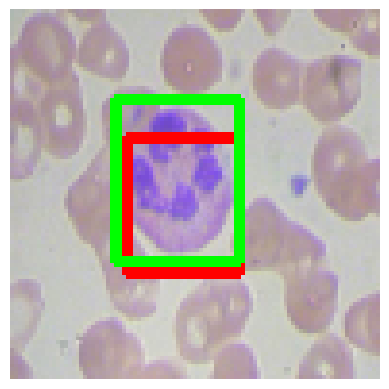

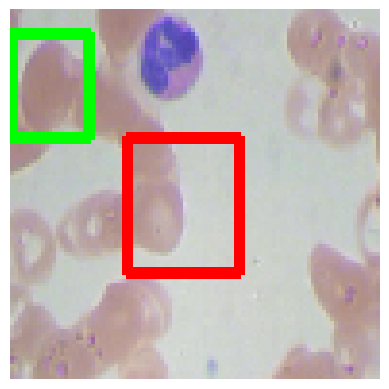

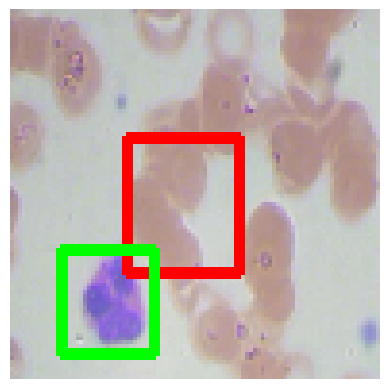

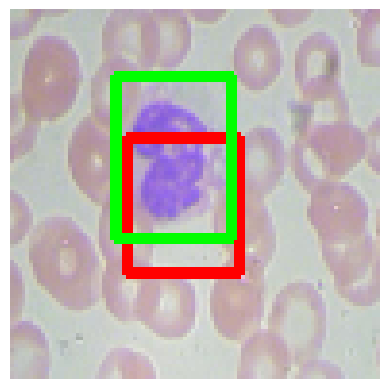

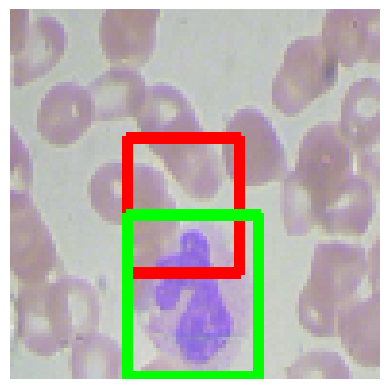

In [ ]:
c = 0
for x, box in DataLoader(BCCD(test_imgs), batch_size=16):
    pred = model(x)

    for i in range(len(x)):
        draw(x[i], pred[i].detach().numpy(), box[i].numpy())
        c += 1
        if c == 5:
            break
    if c == 5:
        break

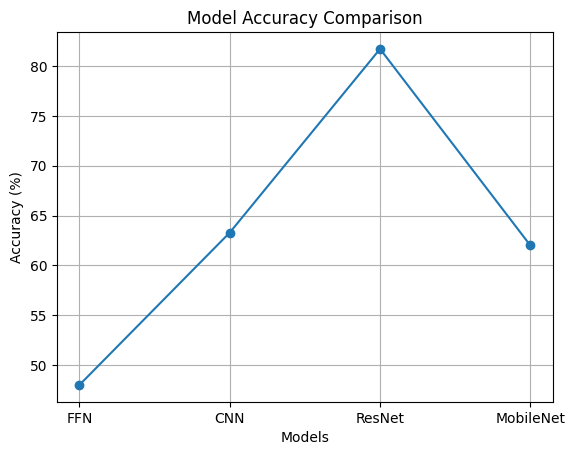

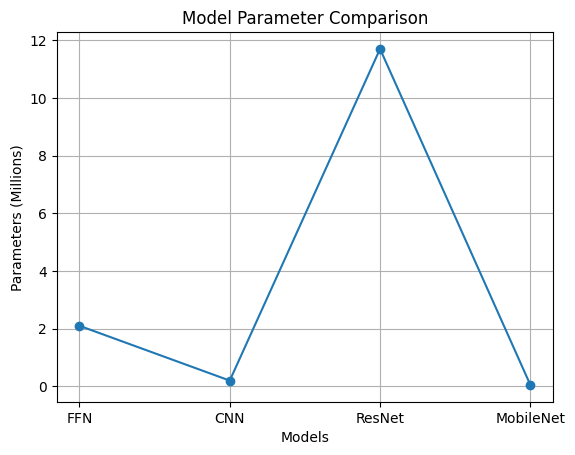

In [3]:
models = ["FFN", "CNN", "ResNet", "MobileNet"]
accuracy = [48, 63.29, 81.73, 62]

params = [2.1, 0.2, 11.7, 0.05]

plt.figure()
plt.plot(models, accuracy, marker='o')
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

plt.figure()
plt.plot(models, params, marker='o')
plt.title("Model Parameter Comparison")
plt.xlabel("Models")
plt.ylabel("Parameters (Millions)")
plt.grid()
plt.show()